## 05 — CNN-Based Locomotion Classifier

Implements a 1-D Convolutional Neural Net for locomotion mode classification,
using the same train/test split and preprocessing pipeline as notebook 04.

- Load and preprocess data using src/utils.py
- Design and train 1D CNN on windowed time segments (window size: 256 samples)
- Input: 4 channels (hand_acc16_y, hand_acc16_z, hand_gyro_x, hand_gyro_y)
- Compare performance against DSP baseline from notebook 04
- Evaluate: accuracy, confusion matrix, F1 score per class

### Data Split
- **Train:** subjects 102, 105, 106, 107, 108 (5 subjects)
- **Validation:** subject101
- **True test set:** not available in this limited dataset with full activity coverage BUT
  - Subject103/104 retained as partial secondary check (walking and stairs only,
    no running data)

### Key question
Does retaining temporal structure in data via convolution help distinguish stair ascent/descent,
where DSP classifier struggled?

### Known Limitations
- Validation is performed on  single held-out subject
- Full generalization testing would require evaluation on additional subject with complete 
activity coverage
   - natural next step beyond this proof of concept

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
import matplotlib.pyplot as plt
%matplotlib widget

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append('..')
import src.utils as utils

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import optuna

In [2]:
# Constants

DATA_DIR = "/Volumes/LPM02 storage/Datasets/Bio/PAMAP2/PAMAP2_Dataset/Protocol"

COL_MAP = {
    'timestamp':    0,
    'activity_id':  1,
    'hand_acc16_y': 4,
    'hand_acc16_z': 5,
    'hand_gyro_x':  8,
    'hand_gyro_y':  9,
}

EXCLUDE_SUBJECTS = ['subject103', 'subject104', 'subject109']  # from EDA, these subjects' data was found to be missing or low quality
VALIDATION_SUBJECT = 'subject101'
PARTIAL_TEST_SUBJECTS = ['subject103', 'subject104']

ACCEL_COLS = ['hand_acc16_y', 'hand_acc16_z']
GYRO_COLS = ['hand_gyro_x', 'hand_gyro_y']
SIGNAL_COLS = ACCEL_COLS + GYRO_COLS

ACTIVITIES = {4: 'Walking', 5: 'Running', 12: 'Stair Ascent', 13: 'Stair Descent'}

FC = 15            # center freq for LPF
FS = 100           # samplerate
WINDOW_SIZE = 256  # for gathering signal "chunks"

# Default hyperparam vals
BATCH_SIZE = 32
N_EPOCHS = 50
LEARNING_RATE = 0.0006577513170280856
WEIGHT_DECAY = 0.00013111936495748124
F1 = 48
F2 = 24
F3 = 64
K1 = 5
K2 = 7
K3 = 9
POOL_K = 2
FC1 = 48
FC2 = 24

## Optuna
# Best trial: 18
# Best val loss: 0.5823
# Best params:
#   f1: 48
#   f2: 24
#   f3: 64
#   k1: 5
#   k2: 7
#   k3: 9
#   fc1: 48
#   fc2: 24
#   lr: 0.0006577513170280856
#   weight_decay: 0.00013111936495748124
#   batch_size: 32

In [3]:
# Load data, keeping only subjects and activities of interest

df_all = utils.load_data(DATA_DIR, COL_MAP)
df_all = utils.exclude_subjects(df_all, EXCLUDE_SUBJECTS)
df_all = utils.filter_activities(df_all, ACTIVITIES)

print(f"Raw: {df_all.shape}")
print(f"Loaded: {df_all.shape[0]} rows, {df_all['subject'].nunique()} subjects")

Raw: (441508, 7)
Loaded: 441508 rows, 6 subjects


In [4]:
# Preprocess data

df_preproc = utils.preprocess(df_all, ACCEL_COLS, GYRO_COLS, fc=FC, fs=FS)

print(f"Preprocessed: {df_preproc.shape}")

Preprocessed: (441508, 7)


In [5]:
# Split data for train/cv/test

# Full training set — all retained subjects except validation subject
df_train, df_val = utils.train_test_split(df_preproc, VALIDATION_SUBJECT)

print(f"Train subjects: {sorted(df_train['subject'].unique())}")
print(f"Validation subject: {sorted(df_val['subject'].unique())}")
print(f"Train shape: {df_train.shape}")
print(f"Val shape: {df_val.shape}")

# Partial test set (subject 103, 104 walking and stairs data)
df_partial = utils.load_data(DATA_DIR, COL_MAP)
df_partial = utils.filter_activities(df_partial, ACTIVITIES)
df_partial = df_partial[df_partial['subject'].isin(PARTIAL_TEST_SUBJECTS)].reset_index(drop=True)
df_partial = utils.preprocess(df_partial, ACCEL_COLS, GYRO_COLS, fc=FC, fs=FS)

# Running data is missing/unreliable for these subjects — walking and stairs only
PARTIAL_ACTIVITIES = {4: 'Walking', 12: 'Stair Ascent', 13: 'Stair Descent'}
df_partial = utils.filter_activities(df_partial, PARTIAL_ACTIVITIES)

print(f"Partial test subjects: {sorted(df_partial['subject'].unique())}")
print(df_partial.groupby(['subject', 'activity_id']).size().unstack())

Train subjects: ['subject102', 'subject105', 'subject106', 'subject107', 'subject108']
Validation subject: ['subject101']
Train shape: (367201, 7)
Val shape: (74307, 7)
Partial test subjects: ['subject103', 'subject104']
activity_id     4      12     13
subject                         
subject103   29036  10389  15275
subject104   31932  16694  14285


In [6]:
# Dataset class

class LocomotionDataset(Dataset):
    """
    PyTorch Dataset for windowed IMU locomotion data.
    
    Extracts fixed-size windows from continuous per-activity time series.
    Each sample is a (4, WINDOW_SIZE) tensor with a corresponding integer label.
    """
    
    def __init__(self, df, signal_cols, activities, window_size):
        self.windows = []
        self.labels = []
        self.activity_to_label = {act_id: i for i, act_id in enumerate(activities.keys())}
    
        for activity_id in activities.keys():
            for subject_id in df['subject'].unique():
                subject_data = df[
                    (df['subject'] == subject_id) &
                    (df['activity_id'] == activity_id)
                ].reset_index(drop=True)
                n_windows = len(subject_data) // window_size
    
                for i in range(n_windows):
                    window = subject_data.iloc[i * window_size:(i + 1) * window_size]
                    tensor = torch.tensor(
                        window[signal_cols].values.T,
                        dtype=torch.float32
                    )
                    self.windows.append(tensor)
                    self.labels.append(self.activity_to_label[activity_id])
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        return self.windows[idx], self.labels[idx]

In [7]:
# Instantiate Dataset and DataLoader classes

train_dataset = LocomotionDataset(df_train, SIGNAL_COLS, ACTIVITIES, WINDOW_SIZE)
val_dataset = LocomotionDataset(df_val, SIGNAL_COLS, ACTIVITIES, WINDOW_SIZE)
partial_dataset = LocomotionDataset(df_partial, SIGNAL_COLS, ACTIVITIES, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
partial_loader = DataLoader(partial_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, batches: {len(train_loader)}")
print(f"Val samples: {len(val_dataset)}, batches: {len(val_loader)}")
print(f"Partial test samples: {len(partial_dataset)}, batches: {len(partial_loader)}")

Train samples: 1425, batches: 45
Val samples: 289, batches: 10
Partial test samples: 456, batches: 15


In [8]:
class LocomotionCNN(nn.Module):
    """
    1D CNN for locomotion mode classification from windowed IMU signals.

    Architecture:
        Conv block 1: Conv1d(n_channels → f1, k=k1) + BN + ReLU
        Conv block 2: Conv1d(f1 → f2, k=k2) + BN + ReLU
        MaxPool1d(k=pool_k)
        Conv block 3: Conv1d(f2 → f3, k=k3) + BN + ReLU
        AdaptiveAvgPool1d(1)
        Flatten
        FC(f3 → fc1, ReLU) → FC(fc1 → fc2, ReLU) → out(fc2 → n_classes)

    Parameters
    ----------
    n_channels : int
        Number of input IMU channels.
    n_classes : int
        Number of output activity classes.
    f1, f2, f3 : int
        Number of filters in each conv block.
    k1, k2, k3 : int
        Kernel sizes for each conv block.
    pool_k : int
        Kernel size for MaxPool1d.
    fc1, fc2 : int
        Hidden sizes for the two fully connected layers.
    """

    def __init__(self, n_channels, n_classes,
                 f1=F1, f2=F2, f3=F3,
                 k1=K1, k2=K2, k3=K3,
                 pool_k=POOL_K,
                 fc1=FC1, fc2=FC2):
        super(LocomotionCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(n_channels, f1, kernel_size=k1),
            nn.BatchNorm1d(f1),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(f1, f2, kernel_size=k2),
            nn.BatchNorm1d(f2),
            nn.ReLU()
        )
        self.pool = nn.MaxPool1d(kernel_size=pool_k)

        self.conv3 = nn.Sequential(
            nn.Conv1d(f2, f3, kernel_size=k3),
            nn.BatchNorm1d(f3),
            nn.ReLU()
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(f3, fc1),
            nn.ReLU(),
            nn.Linear(fc1, fc2),
            nn.ReLU(),
            nn.Linear(fc2, n_classes)
        )


    def forward(self, x, verbose=False):
        if verbose:
            print(f"Input:          {tuple(x.shape)}")
        x = self.conv1(x)
        if verbose:
            print(f"After conv1:    {tuple(x.shape)}")
        x = self.conv2(x)
        if verbose:
            print(f"After conv2:    {tuple(x.shape)}")
        x = self.pool(x)
        if verbose:
            print(f"After pool:     {tuple(x.shape)}")
        x = self.conv3(x)
        if verbose:
            print(f"After conv3:    {tuple(x.shape)}")
        x = self.adaptive_pool(x)
        if verbose:
            print(f"After ap:       {tuple(x.shape)}")
        x = x.squeeze(-1)
        if verbose:
            print(f"After squeeze:  {tuple(x.shape)}")
        x = self.classifier(x)
        if verbose:
            print(f"Output:         {tuple(x.shape)}")
        return x

In [9]:
# Instantiate model

model = LocomotionCNN(n_channels=4, n_classes=4)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params}")

Trainable parameters: 27652


In [10]:
class EarlyStopping:
    """
    Early stopping to halt training when validation loss stops improving.

    Parameters
    ----------
    model : nn.Module
        The model to monitor and save best weights for.
    patience : int
        Number of consecutive epochs without improvement before stopping.
    min_delta : float
        Minimum change in validation loss to qualify as an improvement.
    """

    def __init__(self, model, patience=5, min_delta=0.001):
        self.model = model
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_model_state = None

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = {k: v.clone() for k, v in self.model.state_dict().items()}
        else:
            self.counter += 1

    @property
    def stop(self):
        return self.counter >= self.patience

    def restore_best(self):
        self.model.load_state_dict(self.best_model_state)

Epoch 1/50 | Train loss: 1.2700 | Val loss: 1.1830
Epoch 2/50 | Train loss: 0.9358 | Val loss: 0.9476
Epoch 3/50 | Train loss: 0.6937 | Val loss: 0.8561
Epoch 4/50 | Train loss: 0.5458 | Val loss: 0.7195
Epoch 5/50 | Train loss: 0.4847 | Val loss: 0.8335
Epoch 6/50 | Train loss: 0.4570 | Val loss: 0.6126
Epoch 7/50 | Train loss: 0.4378 | Val loss: 0.8416
Epoch 8/50 | Train loss: 0.3623 | Val loss: 0.7471
Epoch 9/50 | Train loss: 0.3772 | Val loss: 0.7529
Epoch 10/50 | Train loss: 0.3442 | Val loss: 0.9261
Epoch 11/50 | Train loss: 0.3165 | Val loss: 0.8153
Early stopping at epoch 11. Best val loss: 0.6126
Best model weights restored.


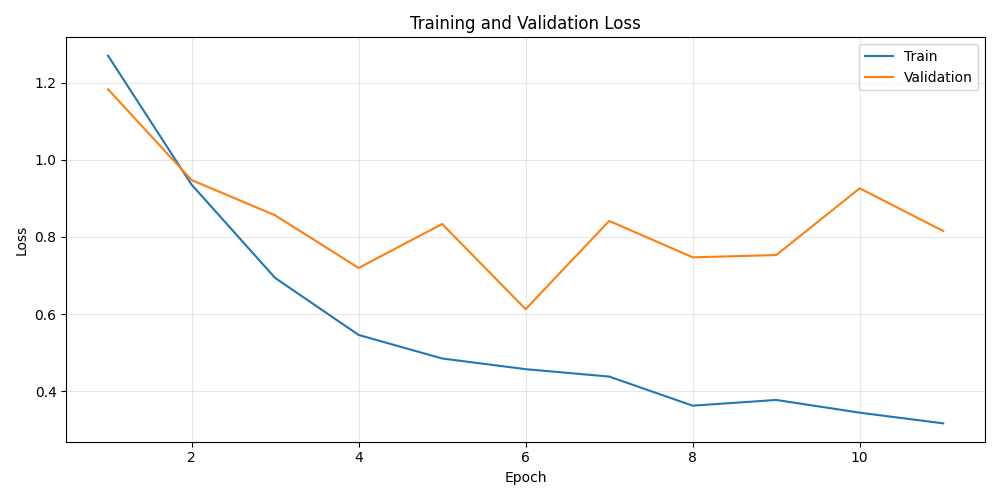

In [11]:
# Training loop

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
early_stopping = EarlyStopping(model, patience=5, min_delta=0.001)

train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    # Training
    model.train()
    epoch_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            epoch_val_loss += loss.item()
    
    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{N_EPOCHS} | Train loss: {epoch_train_loss:.4f} | Val loss: {epoch_val_loss:.4f}")

    early_stopping.step(epoch_val_loss)
    if early_stopping.stop:
        print(f"Early stopping at epoch {epoch+1}. Best val loss: {early_stopping.best_loss:.4f}")
        break

early_stopping.restore_best()
print("Best model weights restored.")

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(train_losses) + 1), train_losses, label='Train')
ax.plot(range(1, len(val_losses) + 1), val_losses, label='Validation')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Evaluation
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        logits = model(batch_X)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(batch_y.numpy())

# Map integer labels back to activity names
label_to_activity = {v: k for k, v in train_dataset.activity_to_label.items()}
activity_names = [ACTIVITIES[label_to_activity[i]] for i in range(len(ACTIVITIES))]

y_true = [activity_names[l] for l in all_labels]
y_pred = [activity_names[p] for p in all_preds]

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=activity_names)
cm_df = pd.DataFrame(cm, index=activity_names, columns=activity_names)
cm_df.index.name = 'True'
cm_df.columns.name = 'Predicted'
print(cm_df)

Accuracy: 0.7993

Classification Report:
               precision    recall  f1-score   support

      Running       1.00      0.93      0.96        83
 Stair Ascent       0.63      0.73      0.68        62
Stair Descent       0.63      0.83      0.72        58
      Walking       0.94      0.71      0.81        86

     accuracy                           0.80       289
    macro avg       0.80      0.80      0.79       289
 weighted avg       0.83      0.80      0.81       289

Predicted      Walking  Running  Stair Ascent  Stair Descent
True                                                        
Walking             61        0            16              9
Running              0       77             0              6
Stair Ascent         4        0            45             13
Stair Descent        0        0            10             48


## Limitations and Hyperparameter Search

### Dataset Limitations

The primary issue in this project is data scarcity:

- 5 training subjects, 1 validation subject
    - data varies between subjects
- 1,433 training windows at WINDOW_SIZE=256
- Stair ascent/descent have fewer windows than walking/running
- Single-fold validation — performance estimates have high variance

Best course of action would be to get more data rather than hyperparameter optimization.

Given the fixed dataset, a structured hyperparameter search is a
reasonable next step to achieve max performance under constraints.

### Hyperparameter Search

Optuna used for hyperparameter optimization

Search space:
- Architecture: filter counts (f1, f2, f3), kernel sizes (k1, k2, k3),
  FC hidden sizes (fc1, fc2)
- Training: learning rate, weight decay, batch size
- Data: window size

Each trial trains a model with early stopping and reports the best validation
loss. The best trial's parameters are used for final evaluation.

# Hyperparam search

import gc
all_train_losses = []
all_val_losses = []

def objective(trial):
    # Sample hyperparameters
    f1 = trial.suggest_int('f1', 8, 64, step=8)
    f2 = trial.suggest_int('f2', 8, 64, step=8)
    f3 = trial.suggest_int('f3', 8, 64, step=8)
    k1 = trial.suggest_int('k1', 3, 11, step=2)
    k2 = trial.suggest_int('k2', 3, 11, step=2)
    k3 = trial.suggest_int('k3', 3, 11, step=2)
    fc1 = trial.suggest_int('fc1', 8, 64, step=8)
    fc2 = trial.suggest_int('fc2', 8, 64, step=8)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # Build model
    trial_model = LocomotionCNN(
        n_channels=len(SIGNAL_COLS),
        n_classes=len(ACTIVITIES),
        f1=f1, f2=f2, f3=f3,
        k1=k1, k2=k2, k3=k3,
        fc1=fc1, fc2=fc2
    )
    trial_optimizer = torch.optim.AdamW(
        trial_model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    trial_criterion = nn.CrossEntropyLoss()
    trial_early_stopping = EarlyStopping(trial_model, patience=5, min_delta=0.001)

    # Training loop
    for epoch in range(50):
        # Train
        trial_model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            trial_optimizer.zero_grad()
            logits = trial_model(batch_X)
            loss = trial_criterion(logits, batch_y)
            loss.backward()
            trial_optimizer.step()
            epoch_train_loss += loss.item()
        epoch_train_loss /= len(train_loader)

        # Validate
        trial_model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                logits = trial_model(batch_X)
                loss = trial_criterion(logits, batch_y)
                epoch_val_loss += loss.item()
        epoch_val_loss /= len(val_loader)

        # Update losses
        all_train_losses.append(epoch_train_loss)
        all_val_losses.append(epoch_val_loss)

        # Early stopping
        trial_early_stopping.step(epoch_val_loss)
        if trial_early_stopping.stop:
            break

    # Memory handling
    del trial_model
    del trial_optimizer
    gc.collect()
    
    return trial_early_stopping.best_loss

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest trial: {study.best_trial.number}")
print(f"Best val loss: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

## Optuna results

Best trial: 18
Best val loss: 0.5823
Best params:
  f1: 48
  f2: 24
  f3: 64
  k1: 5
  k2: 7
  k3: 9
  fc1: 48
  fc2: 24
  lr: 0.0006577513170280856
  weight_decay: 0.00013111936495748124
  batch_size: 32

In [14]:
# Test evaluation after running model with optimal hyperparams

model.eval()

partial_preds = []
partial_labels = []

with torch.no_grad():
    for batch_X, batch_y in partial_loader:
        logits = model(batch_X)
        preds = torch.argmax(logits, dim=1)
        partial_preds.extend(preds.numpy())
        partial_labels.extend(batch_y.numpy())

# Decode ground truth using partial_dataset's own label mapping
partial_label_to_activity = {v: k for k, v in partial_dataset.activity_to_label.items()}
y_true_partial = [ACTIVITIES[partial_label_to_activity[l]] for l in partial_labels]

# Decode predictions using training label space
y_pred_partial = [activity_names[p] for p in partial_preds]

partial_activity_names = ['Walking', 'Stair Ascent', 'Stair Descent']

print("Partial Test Accuracy:", round(accuracy_score(y_true_partial, y_pred_partial), 4))
print("\nClassification Report:")
print(classification_report(y_true_partial, y_pred_partial, labels=partial_activity_names))

cm = confusion_matrix(y_true_partial, y_pred_partial, labels=partial_activity_names)
cm_df = pd.DataFrame(cm, index=partial_activity_names, columns=partial_activity_names)
cm_df.index.name = 'True'
cm_df.columns.name = 'Predicted'
print(cm_df)

Partial Test Accuracy: 0.261

Classification Report:
               precision    recall  f1-score   support

      Walking       0.57      0.03      0.06       237
 Stair Ascent       0.10      0.11      0.11       105
Stair Descent       0.31      0.87      0.46       114

    micro avg       0.26      0.26      0.26       456
    macro avg       0.33      0.34      0.21       456
 weighted avg       0.40      0.26      0.17       456

Predicted      Walking  Stair Ascent  Stair Descent
True                                               
Walking              8           100            129
Stair Ascent         1            12             90
Stair Descent        5            10             99


## Results, Limitations, and Conclusions

### CNN Classifier Performance (subject101 validation)

| Metric | DSP Baseline | CNN (manual) | CNN (Optuna) |
|--------|-------------|--------------|--------------|
| Overall accuracy | 61.3% | 75.1% | 80.0% |
| Running F1 | 0.93 | 0.96 | 0.96 |
| Walking F1 | 0.60 | 0.84 | 0.81 |
| Stair Ascent F1 | 0.51 | 0.55 | 0.68 |
| Stair Descent F1 | 0.24 | 0.49 | 0.72 |

### Key Findings

- CNN outperforms DSP baseline on all classes, suggesting that temporal
  structure is useful classification
- Running is classified accurately by both approaches — amplitude distribution alone is sufficient
- Primary failure mode of DSP clf: stairs (retaining temporal structure using CNN helps)
- Optuna hyperparam search improved stair classification,
    - resulting architecture (increasing kernel sizes, non-monotonic
      filter counts) suggests specific local optimum found

### Generalization — Partial Test Set (subjects 103/104)

- Partial test accuracy: 26.1% — near-random performance on unseen subjects
- Model predicts stair descent for the majority of windows regardless
  of truth
- Walking recall collapses to 0.03 on unseen subjects despite 0.71-0.81 on
  subject101

### Limitations

- **Data scarcity:** 5 training subjects is insufficient for a generalizable
  classifier
- **Obvious overfitting:** huge gap between validation (80%) and partial
  test (26%) reflects the model learning subject-specific signal features
- **Distribution shift:** subjects 103/104 originally excluded from training due to
  data quality issues
    - distributions may differ systematically from training subjects', compounding the generalization problem
- **Single-fold validation:** all validation metrics come from one
  subject (subject101), giving high-variance performance estimates
- **Hyperparameter overfitting:** Optuna likely optimized for subject101 specifically —
  "optimal" params may reflect their signal features rather than generalizable ones
- **Class imbalance:** stair classes had fewer training windows than
  walking/running, likely contributing to the model's instability on unseen subjects

### Theoretical Next Steps or Improvements

- Many more subjects (50-200+) with balanced activity coverage
- Full LOSO cross-validation across all subjects
- Data augmentation during training
- Rigorous held-out test set never used during development